# Day 41 — Clustering for Preprocessing & DBSCAN

- Use clustering as a preprocessing step for supervised learning.
- Understand clustering-assisted semi-supervised learning and label propagation ideas.
- Understand density-based clustering with DBSCAN.
- Understand `eps`, `min_samples`, core points, border points, and noise.
- Experiment with DBSCAN and compare it with K-Means on non-spherical data.


## 1. Clustering as preprocessing

Clustering can discover hidden structure in unlabeled data before a supervised model is trained.

A common workflow is:

`Raw data → Scale/clean → Cluster → Create cluster-based features → Supervised model`

For centroid-based clustering such as K-Means, distances to cluster centroids can be used as additional features.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN

RANDOM_STATE = 42


## 2. Example: clustering-derived features with K-Means

We create synthetic data, fit K-Means, and inspect cluster labels and distances to the centroids.


In [2]:
X_blobs, _ = make_blobs(
    n_samples=500,
    centers=3,
    cluster_std=1.2,
    random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_blobs_scaled = scaler.fit_transform(X_blobs)

kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_blobs_scaled)
cluster_distances = kmeans.transform(X_blobs_scaled)

print("First 10 cluster labels:", cluster_labels[:10])
print("Distance feature shape:", cluster_distances.shape)

cluster_features = pd.DataFrame(
    cluster_distances,
    columns=[f"distance_to_cluster_{i}" for i in range(3)]
)
cluster_features["cluster"] = cluster_labels
cluster_features.head()


First 10 cluster labels: [1 0 0 2 0 0 1 0 0 1]
Distance feature shape: (500, 3)


,distance_to_cluster_0,distance_to_cluster_1,distance_to_cluster_2,cluster
0,2.550819,0.311464,2.631064,1
1,0.660478,2.147254,1.354960,0
2,0.565528,3.133875,2.359292,0
3,1.762878,2.276955,0.288216,2
4,0.310716,2.939401,2.113355,0


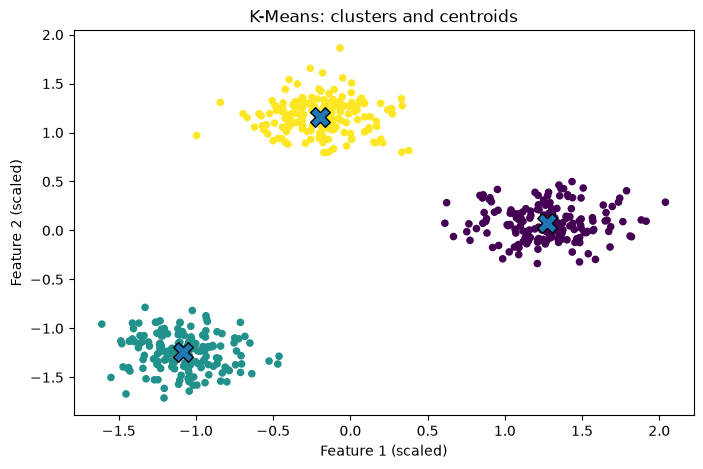

In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(X_blobs_scaled[:, 0], X_blobs_scaled[:, 1], c=cluster_labels, s=20)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200,
    edgecolors="black"
)
plt.title("K-Means: clusters and centroids")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.show()


### Key idea

Instead of using only a categorical cluster ID, centroid distances contain richer information:

`distance_to_cluster_0`, `distance_to_cluster_1`, `distance_to_cluster_2`

These can be supplied as features to a downstream supervised model.


## 3. Semi-supervised learning and label propagation

Semi-supervised learning combines a relatively small amount of labeled data with a larger amount of unlabeled data.

Clustering can help reveal groups of similar observations. If labeled observations are embedded inside these groups, their labels can provide information about nearby unlabeled observations.

Scikit-learn provides `LabelPropagation` and `LabelSpreading` in `sklearn.semi_supervised`.

Use label propagation carefully: a cluster is not automatically a class, and incorrect assumptions can spread incorrect labels.


In [4]:
from sklearn.semi_supervised import LabelPropagation, LabelSpreading

X_semi, y_true = make_blobs(
    n_samples=200,
    centers=2,
    cluster_std=1.0,
    random_state=RANDOM_STATE
)
X_semi = StandardScaler().fit_transform(X_semi)

# In scikit-learn, -1 means "unlabeled".
y_semi = np.full(len(y_true), -1, dtype=int)
y_semi[0] = y_true[0]
y_semi[100] = y_true[100]

label_model = LabelSpreading(kernel="knn", n_neighbors=10)
label_model.fit(X_semi, y_semi)

print("Known labels:", np.sum(y_semi != -1))
print("Propagated classes:", np.unique(label_model.transduction_))


Known labels: 2
Propagated classes: [1]


# 4. DBSCAN — Density-Based Clustering

**DBSCAN** = Density-Based Spatial Clustering of Applications with Noise.

Unlike K-Means, DBSCAN does not require the number of clusters to be specified beforehand. It looks for dense regions and can identify observations that do not belong to any sufficiently dense region.

### Two main parameters

- **`eps`**: neighborhood radius.
- **`min_samples`**: minimum number of samples required in an `eps` neighborhood for a point to be considered a core point. Scikit-learn includes the point itself in this count.

### Point types

- **Core point:** has at least `min_samples` samples in its `eps` neighborhood.
- **Border point:** is not itself a core point but lies within the neighborhood of a core point.
- **Noise point:** does not belong to a sufficiently dense cluster. Scikit-learn represents noise with label `-1`.


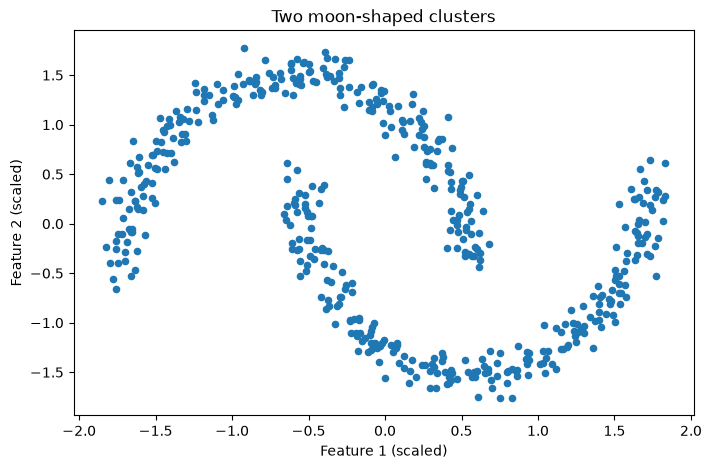

In [5]:
# Two interlocking moon-shaped clusters
X_moons, y_moons = make_moons(
    n_samples=500,
    noise=0.06,
    random_state=RANDOM_STATE
)

X_moons_scaled = StandardScaler().fit_transform(X_moons)

plt.figure(figsize=(8, 5))
plt.scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1], s=20)
plt.title("Two moon-shaped clusters")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.show()


In [6]:
dbscan = DBSCAN(eps=0.25, min_samples=5)
db_labels = dbscan.fit_predict(X_moons_scaled)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = np.sum(db_labels == -1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)
print("Unique labels:", np.unique(db_labels))


Number of clusters: 2
Number of noise points: 0
Unique labels: [0 1]


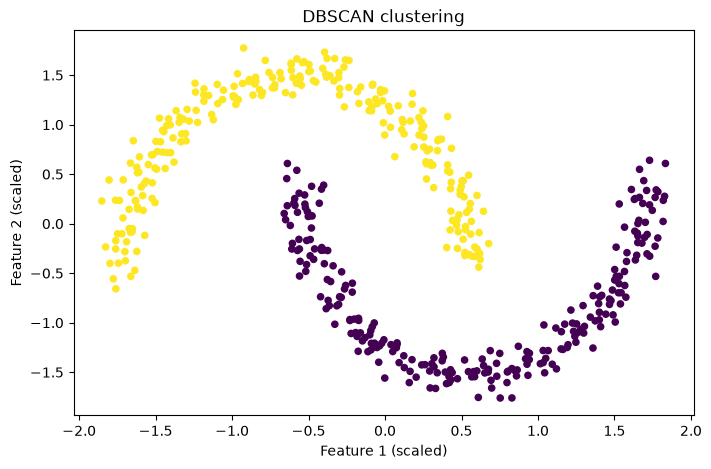

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(
    X_moons_scaled[:, 0],
    X_moons_scaled[:, 1],
    c=db_labels,
    s=20
)
plt.title("DBSCAN clustering")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.show()


## 5. Inspect DBSCAN core samples

`core_sample_indices_` gives the indices of core samples, while `components_` contains the core samples themselves.


In [8]:
core_indices = dbscan.core_sample_indices_
core_samples = dbscan.components_

print("Number of core samples:", len(core_indices))
print("Core sample matrix shape:", core_samples.shape)
print("First 10 core indices:", core_indices[:10])


Number of core samples: 495
Core sample matrix shape: (495, 2)
First 10 core indices: [0 1 2 3 4 5 6 7 8 9]


## 6. Experiment with `eps`

- Too small → many points may become noise or clusters may fragment.
- Reasonable → meaningful dense regions are detected.
- Too large → separate groups may merge.


In [9]:
eps_values = [0.15, 0.20, 0.25, 0.30, 0.40]

results = []
for eps in eps_values:
    model = DBSCAN(eps=eps, min_samples=5)
    labels = model.fit_predict(X_moons_scaled)
    clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = np.sum(labels == -1)
    results.append((eps, clusters, noise))

pd.DataFrame(results, columns=["eps", "clusters", "noise_points"])


,eps,clusters,noise_points
0,0.15,3,14
1,0.20,2,3
2,0.25,2,0
3,0.30,2,0
4,0.40,2,0


## 7. Experiment with `min_samples`

A larger `min_samples` requires a denser neighborhood to create core points. This can increase the number of points treated as noise.


In [10]:
min_samples_values = [3, 5, 8, 12, 20]

results = []
for min_samples in min_samples_values:
    model = DBSCAN(eps=0.25, min_samples=min_samples)
    labels = model.fit_predict(X_moons_scaled)
    clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise = np.sum(labels == -1)
    results.append((min_samples, clusters, noise))

pd.DataFrame(results, columns=["min_samples", "clusters", "noise_points"])


,min_samples,clusters,noise_points
0,3,2,0
1,5,2,0
2,8,2,1
3,12,2,2
4,20,3,33


## 8. Compare K-Means with DBSCAN

K-Means tends to favor compact, centroid-based groups. DBSCAN can discover connected, irregularly shaped dense regions and explicitly identify noise.


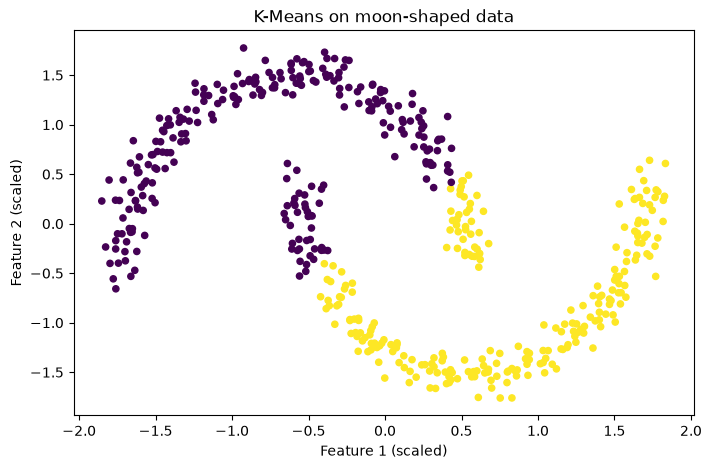

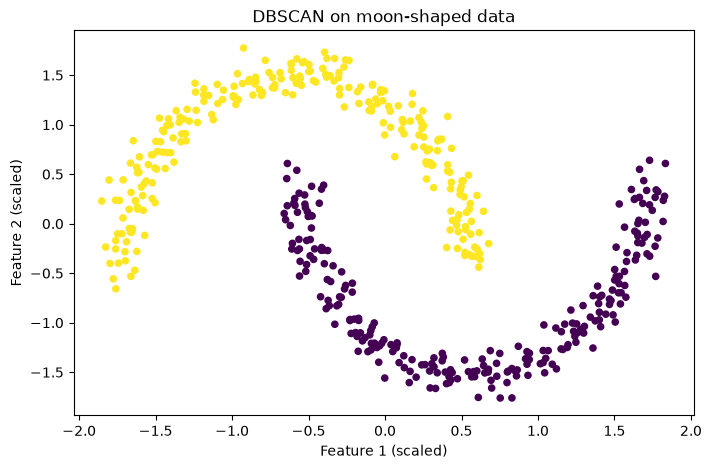

In [11]:
kmeans_moons = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10)
km_labels = kmeans_moons.fit_predict(X_moons_scaled)

dbscan_moons = DBSCAN(eps=0.25, min_samples=5)
db_labels = dbscan_moons.fit_predict(X_moons_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1], c=km_labels, s=20)
plt.title("K-Means on moon-shaped data")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1], c=db_labels, s=20)
plt.title("DBSCAN on moon-shaped data")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.show()


## 9. Why feature scaling matters

DBSCAN relies on distances. If one feature has a much larger numerical scale than another, it can dominate the distance calculation.

Example:

`Age: 20–80` versus `Income: 20,000–500,000`

A common preprocessing step is:

```python
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)
```

For distance-based clustering, always consider scaling and the choice of distance metric.


# 10. DBSCAN limitations

Important limitations:

1. Choosing `eps` can be difficult.
2. A single `eps` value may not work well when clusters have very different densities.
3. Distance-based methods become more challenging in high-dimensional spaces.
4. Results depend strongly on feature scaling and the distance metric.

For datasets with strongly varying densities, algorithms such as HDBSCAN or OPTICS may be worth investigating.


# 11. Day 41 Summary

### Clustering for preprocessing
- Clustering can discover structure before supervised learning.
- Cluster IDs and distances to centroids can become additional features.

### Semi-supervised learning
- Uses both labeled and unlabeled observations.
- Label propagation/spreading uses relationships among samples to infer labels for unlabeled data.

### DBSCAN
- Density-based clustering algorithm.
- `eps` controls neighborhood radius.
- `min_samples` controls how dense a neighborhood must be to form a core point.
- Core points form dense regions.
- Border points lie near core regions but are not themselves core points.
- Noise is represented by `-1` in scikit-learn.
- DBSCAN can find irregularly shaped clusters without specifying the number of clusters beforehand.
